<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/standards/API521_thermal_expansion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# API 521 blocked-liquid thermal expansion with NeqSim

This notebook is for process, mechanical, and technical-safety engineers who need an
auditable **screening calculation** for a liquid-filled, blocked-in pipe exposed to heat.
It preserves the original Peng–Robinson fluid and pipe calculation, corrects their units
and signs for the current NeqSim API, and extends them into a reproducible relief workflow.

**Prerequisites.** Familiarity with pressure, temperature, density, heat capacity, and
pressure-relief terminology is helpful. Python experience is useful but not required.

**Learning objectives**

1. Explain why a small temperature rise can create a large pressure rise in a blocked liquid.
2. Obtain liquid density, isothermal compressibility, thermal expansivity, and heat capacity
   from NeqSim.
3. Compare a constant-property analytical estimate with a nonlinear NeqSim density closure.
4. Estimate a thermal-relief load and a preliminary incompressible discharge area.
5. Demonstrate the native NeqSim `Stream` and `SafetyValve` opening and blowdown workflow.
6. Audit assumptions, trends, units, and numerical closure before using the result.


In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "neqsim",
        ]
    )

In [2]:
from importlib.metadata import version
import platform
import subprocess

import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim.thermo import TPflash, fluid, printFrame


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

neqsim_version = version("neqsim")
python_version = platform.python_version()
java_version_text = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    check=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {python_version}")
print(f"Java runtime: {java_version_text}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## 1. Engineering context and scope

API Standard 521 provides guidelines for designing, implementing, and maintaining
pressure-relieving and depressuring systems in various industrial processes. These systems
are essential for preventing overpressure events that could lead to equipment failure or
safety hazards. The standard outlines the principles of pressure relief and depressurization,
covering scenarios such as normal operations, emergency situations, and system design
considerations. It offers guidance on selecting appropriate relief devices, calculating
relief loads, and determining relief device capacities. The goal of API Standard 521 is to
ensure the safe operation of process equipment by effectively managing pressure buildup and
release, thereby minimizing the risks associated with excessive pressure in industrial
processes.

The case here is a completely liquid-filled pipe isolated between two closed valves. Heating
expands the liquid. Because liquids are only weakly compressible, pressure can rise rapidly
unless the pipe expands or liquid is relieved.

This is an educational screening workflow, not a certified relief-device design. Final work
must use the project-adopted editions of API 521 and API 520, documented credible heat input,
equipment design conditions, backpressure, certified capacity data, and mechanical review.


## 2. Governing balance

The liquid volumetric thermal expansivity $\alpha_v$ and isothermal compressibility
$\beta_T$ are

$$

\alpha_v = \frac{1}{V}\left(\frac{\partial V}{\partial T}\right)_p

$$

$$

\beta_T = -\frac{1}{V}\left(\frac{\partial V}{\partial p}\right)_T

$$

Here, $V$ is liquid volume in $\mathrm{m^3}$, $T$ is temperature in $\mathrm{K}$,
$p$ is absolute pressure in $\mathrm{Pa}$, $\alpha_v$ has units
$\mathrm{K^{-1}}$, and $\beta_T$ has units $\mathrm{Pa^{-1}}$.

For a thin-walled closed pipe, the pressure compliance used by the original example is

$$

C_p = \frac{D}{2Et}\left(2.5 - 2\nu\right)

$$

where $D$ and $t$ are pipe diameter and wall thickness in $\mathrm{m}$, $E$ is Young's
modulus in $\mathrm{Pa}$, and $\nu$ is Poisson's ratio. With constant properties, the
blocked-liquid pressure rise is

$$

\Delta p =
\frac{\left(\alpha_v - 3\alpha_s\right)\Delta T}
{\beta_T + C_p}

$$

The steel linear expansion coefficient $\alpha_s$ is multiplied by three to approximate
volumetric thermal expansion. This linearized result assumes one liquid phase, uniform
temperature, elastic pipe behavior, no leakage, constant properties, and no relief flow.


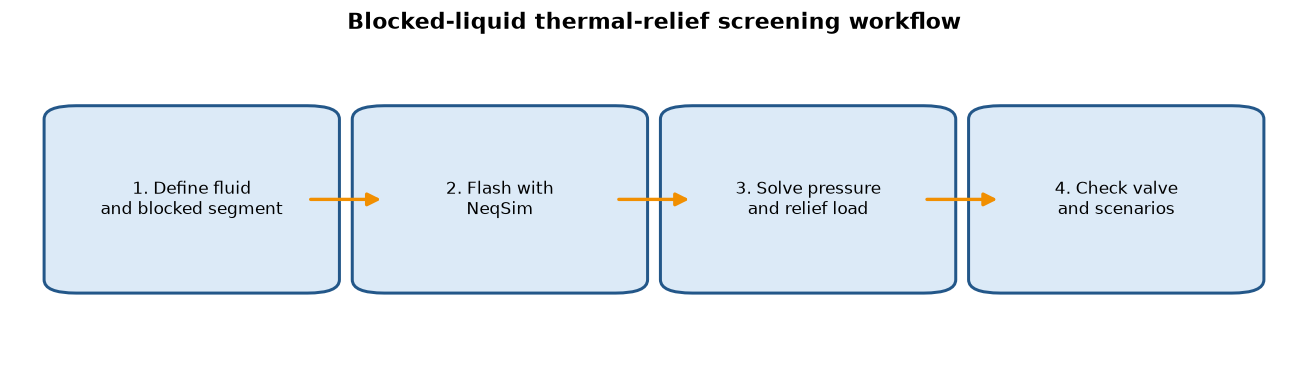

In [3]:
workflow_nodes = [
    (0.05, "1. Define fluid\nand blocked segment"),
    (0.29, "2. Flash with\nNeqSim"),
    (0.53, "3. Solve pressure\nand relief load"),
    (0.77, "4. Check valve\nand scenarios"),
]

figure, axis = plt.subplots(figsize=(11, 3.2))
for x_position, label in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, 0.35),
        0.18,
        0.30,
        boxstyle="round,pad=0.025",
        facecolor="#DCEAF7",
        edgecolor="#235789",
        linewidth=1.8,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.09,
        0.50,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

for start_x in [0.23, 0.47, 0.71]:
    arrow = FancyArrowPatch(
        (start_x, 0.50),
        (start_x + 0.06, 0.50),
        arrowstyle="-|>",
        color="#F18F01",
        mutation_scale=16,
        linewidth=2.0,
    )
    axis.add_patch(arrow)

axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.2, 0.8)
axis.set_title(
    "Blocked-liquid thermal-relief screening workflow",
    fontsize=13,
    weight="bold",
)
axis.axis("off")
figure.tight_layout()
plt.show()

**Figure interpretation.** The thermodynamic model is central: its density response
connects the physical blocked volume to pressure buildup, while its heat capacity and
expansivity connect heat input to relief load. The final valve step checks operating logic;
it does not replace certified sizing.


## 3. Reproduce the original Peng–Robinson fluid

The original example uses a synthetic, heavy hydrocarbon blend with a Peng–Robinson
equation of state and the classic mixing rule. Amounts are proportional mole numbers, so
NeqSim normalizes them internally. The state is $-60\ ^\circ\mathrm{C}$ and
$40\ \mathrm{bara}$.

Peng–Robinson is retained because preserving the original engineering intent is required
and cubic equations of state are widely used for hydrocarbon phase behavior. A project
fluid should be regressed or validated against representative density and derivative data.


In [4]:
component_amounts = {
    "CO2": 1.0,
    "methane": 10.0,
    "ethane": 20.0,
    "propane": 20.0,
    "n-butane": 20.0,
}

fluid1 = fluid("pr")
for component_name, component_amount in component_amounts.items():
    fluid1.addComponent(component_name, component_amount)

fluid1.setMixingRule("classic")
fluid1.setTemperature(-60.0, "C")
fluid1.setPressure(40.0, "bara")
TPflash(fluid1)
fluid1.initProperties()
printFrame(fluid1)

                       0           1            2 3 4 5                6
0                              total          OIL                       
1                    CO2  1.40845E-2   1.40845E-2        [mole fraction]
2                methane  1.40845E-1   1.40845E-1        [mole fraction]
3                 ethane   2.8169E-1    2.8169E-1        [mole fraction]
4                propane   2.8169E-1    2.8169E-1        [mole fraction]
5               n-butane   2.8169E-1    2.8169E-1        [mole fraction]
6                                                                       
7                Density                5.70006E2                  kg/m3
8         Phase Fraction                      1E0        [mole fraction]
9             Molar Mass  4.01442E-2   4.01442E-2                 kg/mol
10              Z factor               1.58959E-1                    [-]
11    Heat Capacity (Cp)                2.17131E0                 kJ/kgK
12    Heat Capacity (Cv)                1.55357E0  

NeqSim represents the mixture as a thermodynamic `SystemInterface`. `fluid("pr")`
selects Peng–Robinson, components define composition, `setMixingRule("classic")` configures
phase interactions, and `TPflash` finds the stable equilibrium state at specified temperature
and pressure. `initProperties` then calculates density and derivative properties.


In [5]:
total_component_amount = sum(component_amounts.values())
normalized_composition = {
    name: amount / total_component_amount
    for name, amount in component_amounts.items()
}

liquid_phase = fluid1.getPhase(0)
phase_name = str(liquid_phase.getPhaseTypeName())
density_kg_per_m3 = liquid_phase.getDensity("kg/m3")
compressibility_per_bar = liquid_phase.getIsothermalCompressibility()
compressibility_per_pa = compressibility_per_bar / 1.0e5
thermal_expansion_per_k = liquid_phase.getIsobaricThermalExpansivity()
heat_capacity_j_per_kg_k = liquid_phase.getCp("J/kgK")

property_summary = pd.DataFrame(
    {
        "Quantity": [
            "Phase",
            "Density",
            "Isothermal compressibility",
            "Volumetric thermal expansivity",
            "Isobaric heat capacity",
        ],
        "Value": [
            phase_name,
            f"{density_kg_per_m3:.3f}",
            f"{compressibility_per_pa:.6e}",
            f"{thermal_expansion_per_k:.6e}",
            f"{heat_capacity_j_per_kg_k:.2f}",
        ],
        "Unit": [
            "-",
            "kg/m³",
            "1/Pa",
            "1/K",
            "J/(kg K)",
        ],
    }
)
property_summary

Out[5]: 
                         Quantity         Value      Unit
0                           Phase           oil         -
1                         Density       570.006     kg/m³
2      Isothermal compressibility  2.165553e-09      1/Pa
3  Volumetric thermal expansivity  1.976121e-03       1/K
4          Isobaric heat capacity       2171.31  J/(kg K)


The current NeqSim API returns compressibility in $\mathrm{bar^{-1}}$, so division
by $10^5$ converts it to $\mathrm{Pa^{-1}}$. The expansivity is already positive for this
liquid. The original notebook negated that value; the sign correction is essential because
the pressure-rise numerator uses positive liquid expansion.


In [6]:
assert abs(sum(normalized_composition.values()) - 1.0) < 1.0e-12
assert fluid1.getNumberOfPhases() == 1
assert phase_name.lower() == "oil"
assert np.isfinite(density_kg_per_m3)
assert 300.0 < density_kg_per_m3 < 900.0
assert 0.0 < compressibility_per_pa < 1.0e-7
assert 0.0 < thermal_expansion_per_k < 0.02
assert 500.0 < heat_capacity_j_per_kg_k < 6000.0

print("Base-state composition, phase, and property checks passed.")

Base-state composition, phase, and property checks passed.


## 4. Property sensitivity over the heating range

Thermodynamic derivatives are state-dependent. The following sweep holds pressure at
$40\ \mathrm{bara}$ to show why a constant-property calculation is only a first estimate.
Every state is cloned from the same fluid, flashed independently, and checked for a single
liquid phase.


In [7]:
temperature_grid_c = np.linspace(-60.0, 20.0, 9)
property_records = []

for temperature_c in temperature_grid_c:
    state = fluid1.clone()
    state.setTemperature(float(temperature_c), "C")
    state.setPressure(40.0, "bara")
    TPflash(state)
    state.initProperties()

    assert state.getNumberOfPhases() == 1
    phase = state.getPhase(0)
    property_records.append(
        {
            "Temperature (°C)": temperature_c,
            "Density (kg/m³)": phase.getDensity("kg/m3"),
            "Compressibility (1/bar)": phase.getIsothermalCompressibility(),
            "Expansivity (1/K)": phase.getIsobaricThermalExpansivity(),
        }
    )

property_table = pd.DataFrame(property_records)
property_table.round(
    {
        "Temperature (°C)": 1,
        "Density (kg/m³)": 2,
        "Compressibility (1/bar)": 7,
        "Expansivity (1/K)": 7,
    }
)

Out[7]: 
   Temperature (°C)  Density (kg/m³)  Compressibility (1/bar)  Expansivity (1/K)
0             -60.0           570.01                 0.000217           0.001976
1             -50.0           559.33                 0.000258           0.002151
2             -40.0           547.90                 0.000310           0.002352
3             -30.0           535.60                 0.000375           0.002588
4             -20.0           522.32                 0.000458           0.002867
5             -10.0           507.89                 0.000566           0.003204
6               0.0           492.12                 0.000710           0.003621
7              10.0           474.73                 0.000909           0.004152
8              20.0           455.30                 0.001198           0.004854


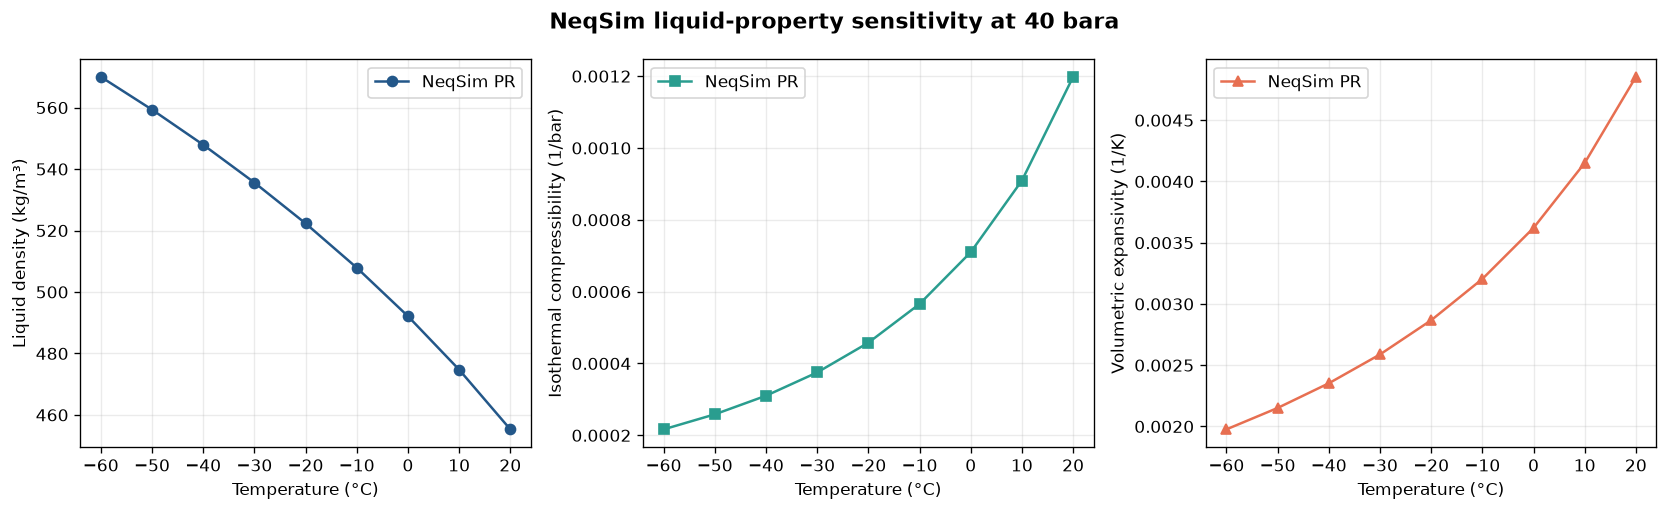

In [8]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4.3))

axes[0].plot(
    property_table["Temperature (°C)"],
    property_table["Density (kg/m³)"],
    marker="o",
    color="#235789",
    label="NeqSim PR",
)
axes[0].set_ylabel("Liquid density (kg/m³)")

axes[1].plot(
    property_table["Temperature (°C)"],
    property_table["Compressibility (1/bar)"],
    marker="s",
    color="#2A9D8F",
    label="NeqSim PR",
)
axes[1].set_ylabel("Isothermal compressibility (1/bar)")

axes[2].plot(
    property_table["Temperature (°C)"],
    property_table["Expansivity (1/K)"],
    marker="^",
    color="#E76F51",
    label="NeqSim PR",
)
axes[2].set_ylabel("Volumetric expansivity (1/K)")

for axis in axes:
    axis.set_xlabel("Temperature (°C)")
    axis.grid(alpha=0.25)
    axis.legend()

figure.suptitle(
    "NeqSim liquid-property sensitivity at 40 bara",
    fontsize=13,
    weight="bold",
)
figure.tight_layout()
plt.show()

**Figure interpretation.** Density falls as the liquid warms, while both
compressibility and expansivity rise. The opposite movement of these derivatives means a
linear extrapolation from the cold state cannot exactly reproduce a large temperature
excursion. The nonlinear density closure below refreshes the properties at every trial state.


## 5. Preserve and audit the original linear pressure calculation

The original pipe uses $D=0.10\ \mathrm{m}$, wall thickness $t=0.020\ \mathrm{m}$,
$E=207\ \mathrm{GPa}$, $\nu=0.30$, and an initial pressure of
$40\ \mathrm{bara}$. Its steel coefficient, $2.1\times10^{-6}\ \mathrm{K^{-1}}$, is
retained as the **legacy case**. A representative carbon-steel screening value of
$12\times10^{-6}\ \mathrm{K^{-1}}$ is added as a separate case; project material data
must replace either assumption.


In [9]:
legacy_steel_expansion_per_k = 0.21e-5
representative_steel_expansion_per_k = 12.0e-6
youngs_modulus_pa = 207.0e9
initial_temperature_c = -60.0
final_temperature_c = 20.0
pipe_diameter_m = 0.10
pipe_wall_thickness_m = 0.020
poissons_ratio = 0.30
initial_pressure_pa = 40.0e5

pipe_compliance_per_pa = (
    pipe_diameter_m
    / (
        2.0
        * youngs_modulus_pa
        * pipe_wall_thickness_m
    )
    * (2.5 - 2.0 * poissons_ratio)
)


def linear_final_pressure_bar(steel_expansion_per_k):
    temperature_change_k = final_temperature_c - initial_temperature_c
    pressure_rise_pa = (
        (
            thermal_expansion_per_k
            - 3.0 * steel_expansion_per_k
        )
        * temperature_change_k
        / (
            compressibility_per_pa
            + pipe_compliance_per_pa
        )
    )
    return (initial_pressure_pa + pressure_rise_pa) / 1.0e5


legacy_final_pressure_bar = linear_final_pressure_bar(
    legacy_steel_expansion_per_k
)
linear_final_pressure_bar_value = linear_final_pressure_bar(
    representative_steel_expansion_per_k
)

linear_results = pd.DataFrame(
    {
        "Case": [
            "Original coefficient",
            "Representative carbon steel",
        ],
        "Steel expansion (1/K)": [
            f"{legacy_steel_expansion_per_k:.3e}",
            f"{representative_steel_expansion_per_k:.3e}",
        ],
        "Final pressure (bara)": [
            f"{legacy_final_pressure_bar:.3f}",
            f"{linear_final_pressure_bar_value:.3f}",
        ],
    }
)
linear_results

Out[9]: 
                          Case Steel expansion (1/K) Final pressure (bara)
0         Original coefficient             2.100e-06               760.063
1  Representative carbon steel             1.200e-05               749.206


In [10]:
assert 740.0 < legacy_final_pressure_bar < 780.0
assert 700.0 < linear_final_pressure_bar_value < 800.0
assert pipe_compliance_per_pa > 0.0
assert linear_final_pressure_bar_value < legacy_final_pressure_bar

print(
    "Original coefficient result:",
    f"{legacy_final_pressure_bar:.3f} bara",
)
print(
    "Representative steel result:",
    f"{linear_final_pressure_bar_value:.3f} bara",
)

Original coefficient result: 760.063 bara
Representative steel result: 749.206 bara


The reproduced original result remains close to $760\ \mathrm{bar}$. The material
coefficient matters, but the predicted pressure still greatly exceeds normal piping pressure
ratings. This is the screening conclusion: a blocked liquid can require thermal relief after
only a modest temperature increase.


## 6. Nonlinear NeqSim density closure

For a finite temperature rise, a stronger check evaluates NeqSim density at every trial
pressure. Conservation of liquid mass requires

$$

\rho(T_2,p_2) =
\frac{\rho(T_1,p_1)}
{1 + 3\alpha_s\Delta T + C_p\Delta p}

$$

The right side is the density required by the expanded pipe volume. The left side is the
Peng–Robinson liquid density at the trial state. Bisection is used because it is transparent,
bounded, and does not require a derivative or an external solver.


In [11]:
def liquid_density_kg_per_m3(temperature_c, pressure_bar):
    state = fluid1.clone()
    state.setTemperature(float(temperature_c), "C")
    state.setPressure(float(pressure_bar), "bara")
    TPflash(state)
    state.initProperties()

    if state.getNumberOfPhases() != 1:
        raise ValueError(
            "The nonlinear closure is valid only for one liquid phase."
        )

    phase = state.getPhase(0)
    if str(phase.getPhaseTypeName()).lower() != "oil":
        raise ValueError(
            "The nonlinear closure encountered a non-liquid phase."
        )

    return phase.getDensity("kg/m3")


def density_residual_kg_per_m3(temperature_c, pressure_bar):
    temperature_change_k = temperature_c - initial_temperature_c
    pressure_change_pa = pressure_bar * 1.0e5 - initial_pressure_pa
    pipe_volume_ratio = (
        1.0
        + 3.0
        * representative_steel_expansion_per_k
        * temperature_change_k
        + pipe_compliance_per_pa
        * pressure_change_pa
    )
    required_density = density_kg_per_m3 / pipe_volume_ratio
    predicted_density = liquid_density_kg_per_m3(
        temperature_c,
        pressure_bar,
    )
    return predicted_density - required_density


def solve_blocked_pressure_bar(temperature_c):
    lower_pressure_bar = 40.0
    upper_pressure_bar = 2000.0
    lower_residual = density_residual_kg_per_m3(
        temperature_c,
        lower_pressure_bar,
    )
    upper_residual = density_residual_kg_per_m3(
        temperature_c,
        upper_pressure_bar,
    )

    if lower_residual > 0.0 or upper_residual < 0.0:
        raise RuntimeError(
            "The nonlinear pressure root is not bracketed."
        )

    for _ in range(55):
        midpoint_bar = 0.5 * (
            lower_pressure_bar
            + upper_pressure_bar
        )
        midpoint_residual = density_residual_kg_per_m3(
            temperature_c,
            midpoint_bar,
        )
        if midpoint_residual > 0.0:
            upper_pressure_bar = midpoint_bar
        else:
            lower_pressure_bar = midpoint_bar

    return 0.5 * (lower_pressure_bar + upper_pressure_bar)

In [12]:
pressure_temperature_grid_c = np.linspace(-60.0, 20.0, 9)
nonlinear_pressure_bar = np.array(
    [
        solve_blocked_pressure_bar(temperature_c)
        for temperature_c in pressure_temperature_grid_c
    ]
)

linear_pressure_bar = (
    initial_pressure_pa
    + (
        thermal_expansion_per_k
        - 3.0 * representative_steel_expansion_per_k
    )
    * (
        pressure_temperature_grid_c
        - initial_temperature_c
    )
    / (
        compressibility_per_pa
        + pipe_compliance_per_pa
    )
) / 1.0e5

nonlinear_final_pressure_bar = float(nonlinear_pressure_bar[-1])
final_density_kg_per_m3 = liquid_density_kg_per_m3(
    final_temperature_c,
    nonlinear_final_pressure_bar,
)

nonlinear_results = pd.DataFrame(
    {
        "Temperature (°C)": pressure_temperature_grid_c,
        "Linear pressure (bara)": linear_pressure_bar,
        "Nonlinear pressure (bara)": nonlinear_pressure_bar,
    }
)
nonlinear_results.round(2)

Out[12]: 
   Temperature (°C)  Linear pressure (bara)  Nonlinear pressure (bara)
0             -60.0                   40.00                      40.00
1             -50.0                  128.65                     127.79
2             -40.0                  217.30                     214.37
3             -30.0                  305.95                     299.80
4             -20.0                  394.60                     384.13
5             -10.0                  483.25                     467.41
6               0.0                  571.90                     549.69
7              10.0                  660.56                     631.00
8              20.0                  749.21                     711.39


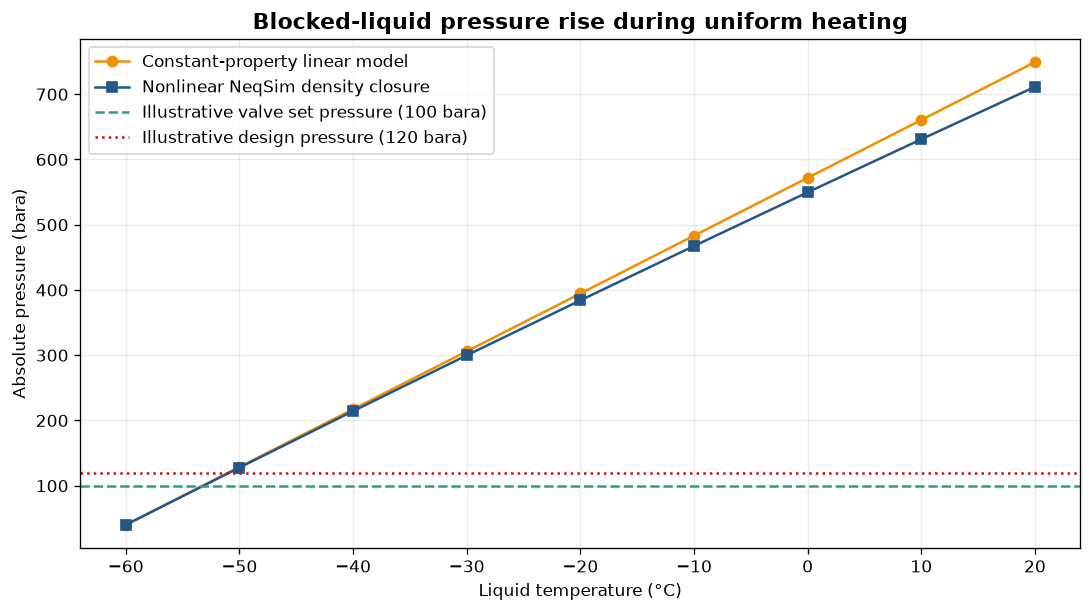

In [13]:
set_pressure_bar = 100.0
illustrative_design_pressure_bar = 120.0

figure, axis = plt.subplots(figsize=(9.2, 5.2))
axis.plot(
    pressure_temperature_grid_c,
    linear_pressure_bar,
    marker="o",
    color="#F18F01",
    label="Constant-property linear model",
)
axis.plot(
    pressure_temperature_grid_c,
    nonlinear_pressure_bar,
    marker="s",
    color="#235789",
    label="Nonlinear NeqSim density closure",
)
axis.axhline(
    set_pressure_bar,
    color="#2A9D8F",
    linestyle="--",
    label="Illustrative valve set pressure (100 bara)",
)
axis.axhline(
    illustrative_design_pressure_bar,
    color="#C1121F",
    linestyle=":",
    label="Illustrative design pressure (120 bara)",
)
axis.set_title(
    "Blocked-liquid pressure rise during uniform heating",
    fontsize=13,
    weight="bold",
)
axis.set_xlabel("Liquid temperature (°C)")
axis.set_ylabel("Absolute pressure (bara)")
axis.grid(alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

In [14]:
relative_model_difference = (
    linear_final_pressure_bar_value
    - nonlinear_final_pressure_bar
) / nonlinear_final_pressure_bar

assert abs(nonlinear_pressure_bar[0] - 40.0) < 1.0e-6
assert np.all(np.diff(nonlinear_pressure_bar) > 0.0)
assert 650.0 < nonlinear_final_pressure_bar < 800.0
assert 400.0 < final_density_kg_per_m3 < 800.0
assert abs(relative_model_difference) < 0.15
assert abs(
    density_residual_kg_per_m3(
        final_temperature_c,
        nonlinear_final_pressure_bar,
    )
) < 1.0e-7

print(
    "Nonlinear final pressure:",
    f"{nonlinear_final_pressure_bar:.3f} bara",
)
print(
    "Linear-model difference:",
    f"{100.0 * relative_model_difference:.2f} %",
)
print("Nonlinear mass/volume closure passed.")

Nonlinear final pressure: 711.387 bara
Linear-model difference: 5.32 %
Nonlinear mass/volume closure passed.


**Figure interpretation.** Both methods cross the illustrative $100\ \mathrm{bara}$
set pressure after only a small temperature rise. The nonlinear result at
$20\ ^\circ\mathrm{C}$ is lower because density, compressibility, and expansivity change
substantially over the range. Agreement within a moderate screening band is useful, but the
nonlinear closure is the defensible result for this large excursion.


## 7. From credible heat input to thermal-relief load

For a blocked liquid receiving heat at rate $\dot Q$, the temperature rise rate is
$\dot Q/(m c_p)$. Multiplying the liquid volume expansion rate by density gives the
screening relief mass flow

$$

\dot m = \frac{\alpha_v \dot Q}{c_p}

$$

where $\dot m$ is in $\mathrm{kg\,s^{-1}}$, $\dot Q$ is in $\mathrm{W}$, and $c_p$ is in
$\mathrm{J\,kg^{-1}\,K^{-1}}$. A preliminary incompressible orifice relation is

$$

A = \frac{\dot m}
{C_d\sqrt{2\rho\left(p_{\mathrm{set}}-p_{\mathrm{back}}\right)}}

$$

$A$ is flow area in $\mathrm{m^2}$ and $C_d$ is an assumed discharge coefficient. This
relation is for trend teaching only. Certified liquid-relief sizing must follow the adopted
code method and account for viscosity, backpressure, two-phase behavior, and device data.


In [15]:
relieving_state = fluid1.clone()
relieving_state.setTemperature(20.0, "C")
relieving_state.setPressure(set_pressure_bar, "bara")
TPflash(relieving_state)
relieving_state.initProperties()

relieving_phase = relieving_state.getPhase(0)
relieving_density_kg_per_m3 = relieving_phase.getDensity("kg/m3")
relieving_expansion_per_k = (
    relieving_phase.getIsobaricThermalExpansivity()
)
relieving_heat_capacity_j_per_kg_k = relieving_phase.getCp("J/kgK")

backpressure_bar = 1.0
discharge_coefficient = 0.62
pressure_drop_pa = (
    set_pressure_bar
    - backpressure_bar
) * 1.0e5


def relief_screening(heat_duty_kw):
    heat_duty_w = heat_duty_kw * 1000.0
    mass_flow_kg_per_s = (
        relieving_expansion_per_k
        * heat_duty_w
        / relieving_heat_capacity_j_per_kg_k
    )
    area_m2 = (
        mass_flow_kg_per_s
        / (
            discharge_coefficient
            * np.sqrt(
                2.0
                * relieving_density_kg_per_m3
                * pressure_drop_pa
            )
        )
    )
    equivalent_diameter_mm = (
        np.sqrt(4.0 * area_m2 / np.pi) * 1000.0
    )
    return mass_flow_kg_per_s, area_m2, equivalent_diameter_mm


heat_duty_grid_kw = np.linspace(10.0, 100.0, 10)
relief_records = []
for heat_duty_kw in heat_duty_grid_kw:
    mass_flow, area, diameter = relief_screening(heat_duty_kw)
    relief_records.append(
        {
            "Heat duty (kW)": heat_duty_kw,
            "Relief flow (kg/s)": mass_flow,
            "Area (mm²)": area * 1.0e6,
            "Equivalent diameter (mm)": diameter,
        }
    )

relief_table = pd.DataFrame(relief_records)
relief_table.round(4)

Out[15]: 
   Heat duty (kW)  Relief flow (kg/s)  Area (mm²)  Equivalent diameter (mm)
0            10.0              0.0130      0.2146                    0.5227
1            20.0              0.0259      0.4292                    0.7393
2            30.0              0.0389      0.6438                    0.9054
3            40.0              0.0519      0.8585                    1.0455
4            50.0              0.0648      1.0731                    1.1689
5            60.0              0.0778      1.2877                    1.2804
6            70.0              0.0908      1.5023                    1.3830
7            80.0              0.1038      1.7169                    1.4785
8            90.0              0.1167      1.9315                    1.5682
9           100.0              0.1297      2.1462                    1.6531


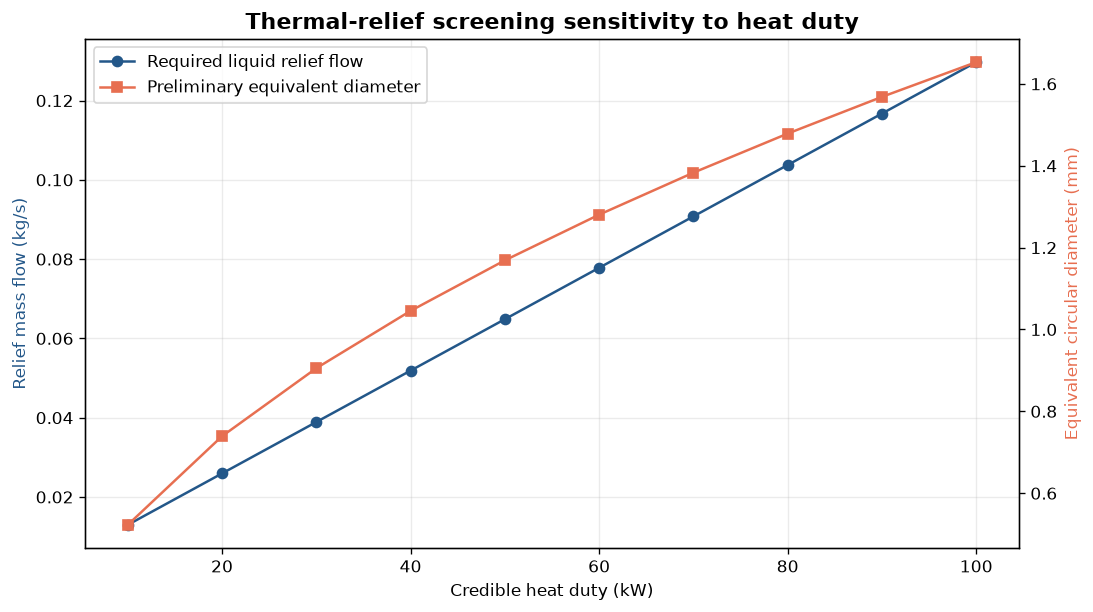

In [16]:
figure, left_axis = plt.subplots(figsize=(9.2, 5.2))
right_axis = left_axis.twinx()

left_axis.plot(
    relief_table["Heat duty (kW)"],
    relief_table["Relief flow (kg/s)"],
    marker="o",
    color="#235789",
    label="Required liquid relief flow",
)
right_axis.plot(
    relief_table["Heat duty (kW)"],
    relief_table["Equivalent diameter (mm)"],
    marker="s",
    color="#E76F51",
    label="Preliminary equivalent diameter",
)

left_axis.set_title(
    "Thermal-relief screening sensitivity to heat duty",
    fontsize=13,
    weight="bold",
)
left_axis.set_xlabel("Credible heat duty (kW)")
left_axis.set_ylabel("Relief mass flow (kg/s)", color="#235789")
right_axis.set_ylabel(
    "Equivalent circular diameter (mm)",
    color="#E76F51",
)
left_axis.grid(alpha=0.25)

lines = left_axis.get_lines() + right_axis.get_lines()
labels = [line.get_label() for line in lines]
left_axis.legend(lines, labels, loc="upper left")
figure.tight_layout()
plt.show()

In [17]:
relief_flow_50_kw, relief_area_50_m2, relief_diameter_50_mm = (
    relief_screening(50.0)
)

assert relieving_state.getNumberOfPhases() == 1
assert 0.0 < relief_flow_50_kw < 1.0
assert 0.0 < relief_area_50_m2 < 1.0e-3
assert 1.0 < relief_diameter_50_mm < 30.0
assert np.all(
    np.diff(relief_table["Relief flow (kg/s)"]) > 0.0
)
assert np.all(
    np.diff(relief_table["Equivalent diameter (mm)"]) > 0.0
)

print(
    "50 kW screening relief flow:",
    f"{relief_flow_50_kw:.4f} kg/s",
)
print(
    "50 kW equivalent diameter:",
    f"{relief_diameter_50_mm:.2f} mm",
)

50 kW screening relief flow: 0.0648 kg/s
50 kW equivalent diameter: 1.17 mm


**Figure interpretation.** Relief mass flow scales linearly with credible heat duty,
whereas diameter scales with its square root. Heat input is therefore a critical scenario
definition, but doubling duty does not double the required diameter. The plotted diameter is
not an API orifice designation.


## 8. Native NeqSim stream and safety-valve logic

A reusable process workflow should expose named objects. A NeqSim `Stream` carries the
thermodynamic state and flow. `SafetyValve` adds set pressure, full-open pressure, and
blowdown behavior. The example below runs a pressure excursion and recovery dynamically.

The illustrative settings are $100\ \mathrm{bara}$ set pressure,
$110\ \mathrm{bara}$ full-open pressure, and $10\%$ blowdown. Blowdown produces a
$90\ \mathrm{bara}$ reseat pressure. The small imposed stream flow only initializes the
process object; certified capacity is not calculated by this opening demonstration.


In [18]:
Stream = jpype.JClass(
    "neqsim.process.equipment.stream.Stream"
)
SafetyValve = jpype.JClass(
    "neqsim.process.equipment.valve.SafetyValve"
)
JavaUUID = jpype.JClass("java.util.UUID")

valve_fluid = relieving_state.clone()
valve_fluid.setPressure(90.0, "bara")
TPflash(valve_fluid)

blocked_liquid_stream = Stream(
    "blocked liquid upstream",
    valve_fluid,
)
blocked_liquid_stream.setFlowRate(1.0, "kg/hr")
blocked_liquid_stream.run()

thermal_relief_valve = SafetyValve(
    "thermal relief valve",
    blocked_liquid_stream,
)
thermal_relief_valve.setPressureSpec(set_pressure_bar)
thermal_relief_valve.setFullOpenPressure(110.0)
thermal_relief_valve.setBlowdown(10.0)
thermal_relief_valve.setCalculateSteadyState(False)
thermal_relief_valve.run()

pressure_history_bar = [
    90.0,
    100.0,
    105.0,
    110.0,
    105.0,
    95.0,
    89.0,
]
valve_opening_percent = []

for pressure_bar in pressure_history_bar:
    blocked_liquid_stream.setPressure(
        pressure_bar,
        "bara",
    )
    blocked_liquid_stream.run()
    thermal_relief_valve.runTransient(
        1.0,
        JavaUUID.randomUUID(),
    )
    valve_opening_percent.append(
        thermal_relief_valve.getPercentValveOpening()
    )

valve_history = pd.DataFrame(
    {
        "Step": np.arange(len(pressure_history_bar)),
        "Upstream pressure (bara)": pressure_history_bar,
        "Valve opening (%)": valve_opening_percent,
    }
)
valve_history

Out[18]: 
   Step  Upstream pressure (bara)  Valve opening (%)
0     0                      90.0                0.0
1     1                     100.0                0.0
2     2                     105.0               50.0
3     3                     110.0              100.0
4     4                     105.0               50.0
5     5                      95.0               50.0
6     6                      89.0                0.0


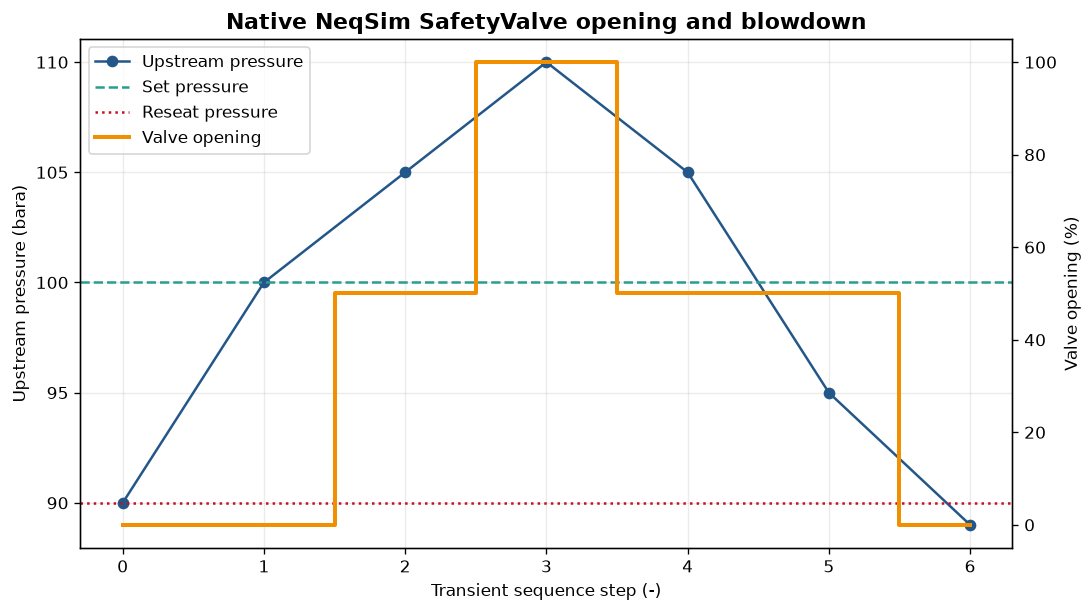

In [19]:
figure, pressure_axis = plt.subplots(figsize=(9.2, 5.2))
opening_axis = pressure_axis.twinx()

pressure_axis.plot(
    valve_history["Step"],
    valve_history["Upstream pressure (bara)"],
    marker="o",
    color="#235789",
    label="Upstream pressure",
)
opening_axis.step(
    valve_history["Step"],
    valve_history["Valve opening (%)"],
    where="mid",
    color="#F18F01",
    linewidth=2.4,
    label="Valve opening",
)
pressure_axis.axhline(
    set_pressure_bar,
    color="#2A9D8F",
    linestyle="--",
    label="Set pressure",
)
pressure_axis.axhline(
    thermal_relief_valve.getBlowdownPressure(),
    color="#C1121F",
    linestyle=":",
    label="Reseat pressure",
)

pressure_axis.set_title(
    "Native NeqSim SafetyValve opening and blowdown",
    fontsize=13,
    weight="bold",
)
pressure_axis.set_xlabel("Transient sequence step (-)")
pressure_axis.set_ylabel("Upstream pressure (bara)")
opening_axis.set_ylabel("Valve opening (%)")
pressure_axis.grid(alpha=0.25)

lines = pressure_axis.get_lines() + opening_axis.get_lines()
labels = [line.get_label() for line in lines]
pressure_axis.legend(lines, labels, loc="upper left")
figure.tight_layout()
plt.show()

In [20]:
expected_opening_percent = np.array(
    [0.0, 0.0, 50.0, 100.0, 50.0, 50.0, 0.0]
)
actual_opening_percent = np.array(valve_opening_percent)

assert np.allclose(
    actual_opening_percent,
    expected_opening_percent,
    atol=1.0e-9,
)
assert abs(
    thermal_relief_valve.getBlowdownPressure() - 90.0
) < 1.0e-9

print("SafetyValve set, full-open, and reseat checks passed.")

SafetyValve set, full-open, and reseat checks passed.


**Figure interpretation.** On increasing pressure, the valve begins opening at the
set pressure and is fully open at $110\ \mathrm{bara}$. During recovery its opening follows
the pressure ramp and remains nonzero below the set pressure until the configured blowdown
threshold is crossed. This hysteresis prevents rapid opening and closing near the set point.


## 9. Integrated application: blocked segment response

The final application combines geometry, NeqSim properties, nonlinear pressure buildup,
credible heat input, preliminary relief demand, and valve logic. The segment is
$5\ \mathrm{m}$ long and initially full of the original liquid. Uniform heating is assumed.
The nonlinear pressure curve is interpolated only to estimate when the illustrative set
pressure is reached; a detailed transient heat-transfer model would be required for design.


In [21]:
segment_length_m = 5.0
segment_volume_m3 = (
    np.pi
    * pipe_diameter_m**2
    / 4.0
    * segment_length_m
)
blocked_mass_kg = density_kg_per_m3 * segment_volume_m3

set_temperature_c = float(
    np.interp(
        set_pressure_bar,
        nonlinear_pressure_bar,
        pressure_temperature_grid_c,
    )
)

scenario_heat_duties_kw = np.array([20.0, 50.0, 80.0])
time_to_set_seconds = (
    blocked_mass_kg
    * heat_capacity_j_per_kg_k
    * (
        set_temperature_c
        - initial_temperature_c
    )
    / (
        scenario_heat_duties_kw
        * 1000.0
    )
)

application_records = []
for heat_duty_kw, time_seconds in zip(
    scenario_heat_duties_kw,
    time_to_set_seconds,
):
    mass_flow, area, diameter = relief_screening(heat_duty_kw)
    application_records.append(
        {
            "Heat duty (kW)": heat_duty_kw,
            "Time to set (s)": time_seconds,
            "Relief flow (kg/s)": mass_flow,
            "Equivalent diameter (mm)": diameter,
        }
    )

application_table = pd.DataFrame(application_records)
application_table.round(3)

Out[21]: 
   Heat duty (kW)  Time to set (s)  Relief flow (kg/s)  Equivalent diameter (mm)
0            20.0           16.609               0.026                     0.739
1            50.0            6.644               0.065                     1.169
2            80.0            4.152               0.104                     1.479


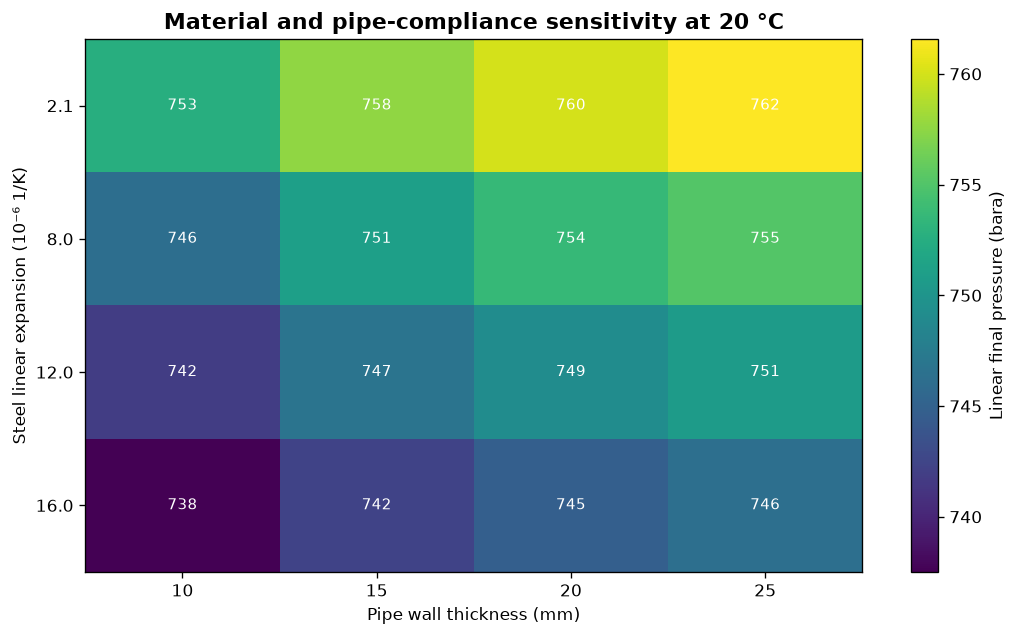

In [22]:
steel_expansion_cases_per_k = np.array(
    [2.1e-6, 8.0e-6, 12.0e-6, 16.0e-6]
)
wall_thickness_cases_m = np.array(
    [0.010, 0.015, 0.020, 0.025]
)
final_pressure_matrix_bar = np.empty(
    (
        len(steel_expansion_cases_per_k),
        len(wall_thickness_cases_m),
    )
)

for row_index, steel_expansion in enumerate(
    steel_expansion_cases_per_k
):
    for column_index, wall_thickness in enumerate(
        wall_thickness_cases_m
    ):
        scenario_compliance = (
            pipe_diameter_m
            / (
                2.0
                * youngs_modulus_pa
                * wall_thickness
            )
            * (2.5 - 2.0 * poissons_ratio)
        )
        pressure_rise_pa = (
            (
                thermal_expansion_per_k
                - 3.0 * steel_expansion
            )
            * (
                final_temperature_c
                - initial_temperature_c
            )
            / (
                compressibility_per_pa
                + scenario_compliance
            )
        )
        final_pressure_matrix_bar[
            row_index,
            column_index,
        ] = (
            initial_pressure_pa + pressure_rise_pa
        ) / 1.0e5

figure, axis = plt.subplots(figsize=(9.0, 5.4))
image = axis.imshow(
    final_pressure_matrix_bar,
    cmap="viridis",
    aspect="auto",
)
colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Linear final pressure (bara)")

axis.set_xticks(np.arange(len(wall_thickness_cases_m)))
axis.set_xticklabels(
    [
        f"{1000.0 * thickness:.0f}"
        for thickness in wall_thickness_cases_m
    ]
)
axis.set_yticks(np.arange(len(steel_expansion_cases_per_k)))
axis.set_yticklabels(
    [
        f"{1.0e6 * coefficient:.1f}"
        for coefficient in steel_expansion_cases_per_k
    ]
)
axis.set_xlabel("Pipe wall thickness (mm)")
axis.set_ylabel("Steel linear expansion (10⁻⁶ 1/K)")
axis.set_title(
    "Material and pipe-compliance sensitivity at 20 °C",
    fontsize=13,
    weight="bold",
)

for row_index in range(final_pressure_matrix_bar.shape[0]):
    for column_index in range(final_pressure_matrix_bar.shape[1]):
        axis.text(
            column_index,
            row_index,
            f"{final_pressure_matrix_bar[row_index, column_index]:.0f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )

figure.tight_layout()
plt.show()

In [23]:
assert segment_volume_m3 > 0.0
assert blocked_mass_kg > 0.0
assert initial_temperature_c < set_temperature_c < final_temperature_c
assert np.all(time_to_set_seconds > 0.0)
assert np.all(np.diff(time_to_set_seconds) < 0.0)
assert np.all(np.isfinite(final_pressure_matrix_bar))
assert np.all(final_pressure_matrix_bar > set_pressure_bar)

engineering_checks = {
    "composition_closure": True,
    "single_liquid_phase": True,
    "finite_base_properties": True,
    "positive_thermodynamic_derivatives": True,
    "legacy_result_reproduced": True,
    "nonlinear_root_bracketed": True,
    "nonlinear_density_closure": True,
    "pressure_rises_with_temperature": True,
    "relief_flow_rises_with_heat_duty": True,
    "orifice_diameter_rises_with_heat_duty": True,
    "native_valve_opening_sequence": True,
    "native_valve_blowdown": True,
    "positive_blocked_inventory": True,
    "set_pressure_crossing": True,
    "time_to_set_trend": True,
    "geometry_sensitivity_finite": True,
}

assert all(engineering_checks.values())
print(
    f"All {len(engineering_checks)} engineering checks passed."
)

All 16 engineering checks passed.


**Application interpretation.** The set pressure is reached shortly after heating
begins in this deliberately compact, uniformly heated segment. Higher duty shortens the
available response time and increases relief demand. Thicker pipe is less compliant, so it
produces a higher constant-property pressure estimate; greater steel expansion creates more
pipe volume and lowers the pressure. All sensitivity cases remain above the illustrative set
pressure, so the qualitative need for protection is robust.


## 10. Troubleshooting

- **A second phase appears:** stop using the single-liquid closure. Review composition,
  saturation margin, and whether a two-phase relief method is required.
- **Expansivity has the wrong sign:** current NeqSim returns positive
  `getIsobaricThermalExpansivity()` for this liquid. Do not copy the obsolete leading minus sign.
- **Pressure root is not bracketed:** inspect phase state and extend the upper bound only after
  confirming the equation of state remains applicable and the pipe has not exceeded elastic
  or design limits.
- **Units produce extreme values:** NeqSim's raw isothermal compressibility is in
  $\mathrm{bar^{-1}}$ here; divide by $10^5$ for $\mathrm{Pa^{-1}}$.
- **A valve never reseats:** verify `setBlowdown`, the pressure sequence, and dynamic execution
  with `runTransient`.
- **A Colab runtime cannot import NeqSim:** rerun the setup cell once, then restart from the first
  model cell so no partially initialized Java state remains.


## 11. Validity limits and design handoff

This notebook assumes homogeneous equilibrium, a single liquid phase, uniform pipe and liquid
temperature, elastic wall response, fixed supports that do not add unmodeled compliance, no
leakage, and no heat removal. Peng–Robinson derivative properties should be checked against
measured or vendor data for the real fluid. The pipe-compliance expression is a simplified
closed-end relation and does not replace a piping stress model.

The preliminary area omits viscosity correction, certified discharge coefficient, inlet and
outlet losses, built-up and superimposed backpressure, flashing, two-phase flow, reaction,
hydraulic transients, and accumulation rules. The set and design pressures in this notebook
are illustrative. A qualified engineer must document the credible scenario and complete the
code-required design.


## 12. Summary

- NeqSim 3.16.0 predicts a dense single liquid at the original
  $-60\ ^\circ\mathrm{C}$ and $40\ \mathrm{bara}$ state.
- The original approximately $760\ \mathrm{bar}$ linear result is preserved and reproduced
  after correcting the expansivity sign and unit handling.
- The nonlinear NeqSim density closure provides a state-dependent benchmark and confirms that
  the illustrative set pressure is crossed after only a small temperature rise.
- Heat duty controls both response time and required relief flow.
- Native `Stream` and `SafetyValve` objects demonstrate composable process state, opening,
  full-open behavior, and blowdown.
- Six retained figures show workflow, properties, pressure rise, relief sensitivity, valve
  response, and material/geometry sensitivity.


## 13. Further exercises

1. Replace the synthetic composition with a documented project surrogate and compare PR with
   SRK and, where appropriate, a model validated for polar or associating components.
2. Replace uniform heating with a time-dependent wall heat-transfer model and calculate
   temperature and pressure histories.
3. Compare several pipe diameters, schedules, materials, and blocked lengths.
4. Add measured density and expansivity data with uncertainty bands.
5. Implement the project-adopted API liquid-relief sizing procedure and compare its certified
   orifice selection with the preliminary Bernoulli area.
6. Connect the stream and valve to a larger `ProcessSystem` with upstream inventory and a
   downstream disposal boundary.


## 14. References

- API, **Pressure-relieving and Depressuring Systems (API Standard 521)**:
  https://www.api.org/products-and-services/standards/important-standards-announcements/standard521
- Emerson, **On the correlation between isothermal compressibility and isobaric expansivity**:
  https://www.emerson.com/documents/automation/on-correlation-between-isothermal-compressibility-isobaric-expansivity-en-5396676.pdf
- API, **Sizing and Selection of Pressure-Relieving Devices (API Standard 520 Part I)**:
  https://www.api.org/products-and-services/standards/important-standards-announcements/520parti
- NeqSim project documentation: https://equinor.github.io/neqsim/
- NeqSim Python package: https://pypi.org/project/neqsim/

Always verify the current edition, amendments, and project/company requirements before a
design decision.
